In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Walmart_cleaned_data.csv")

print (df)

        Store  Dept  Weekly_Sales  Isholiday  Temperature  Fuel_Price  \
0           1     1      24924.50      False        42.31       2.572   
1           1     1      46039.49       True        38.51       2.548   
2           1     1      41595.55      False        39.93       2.514   
3           1     1      19403.54      False        46.63       2.561   
4           1     1      21827.90      False        46.50       2.625   
...       ...   ...           ...        ...          ...         ...   
421565     45    98        508.37      False        64.88       3.997   
421566     45    98        628.10      False        64.89       3.985   
421567     45    98       1061.02      False        54.47       4.000   
421568     45    98        760.01      False        56.47       3.969   
421569     45    98       1076.80      False        58.85       3.882   

        MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0            0.00       0.00       0.00       

In [4]:
X = df.drop("Weekly_Sales", axis = 1)
Y = df["Weekly_Sales"]

In [5]:
train = df[df["Year"] < 2012]
test = df[df["Year"] == 2012]

X_train = train.drop("Weekly_Sales", axis = 1)
Y_train = train["Weekly_Sales"]

X_test = test.drop("Weekly_Sales", axis = 1)
Y_test = test["Weekly_Sales"]

print(X_train.shape)
print(X_test.shape)


(294132, 18)
(127438, 18)


In [6]:
print(X_train.dtypes)

Store             int64
Dept              int64
Isholiday          bool
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
Size              int64
Year              int64
Month             int64
Week              int64
Type_B             bool
Type_C             bool
dtype: object


In [7]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 6, 
    random_state = 42
)

model.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [8]:
Y_pred = model.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error,r2_score
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 3469.46944659694
R2 Score: 0.9285347378226275


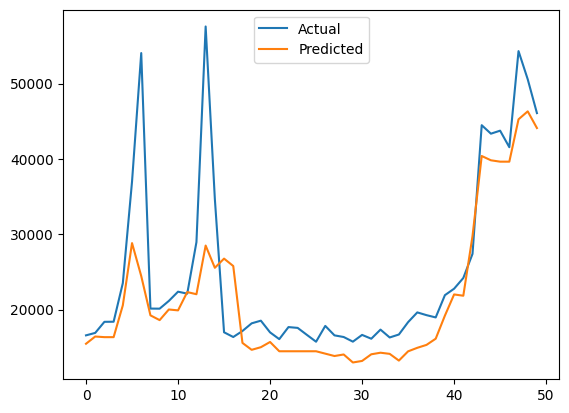

In [10]:
plt.plot(Y_test.values[:50], label = "Actual")
plt.plot(Y_pred[:50], label = "Predicted")
plt.legend()
plt.show()

<Axes: >

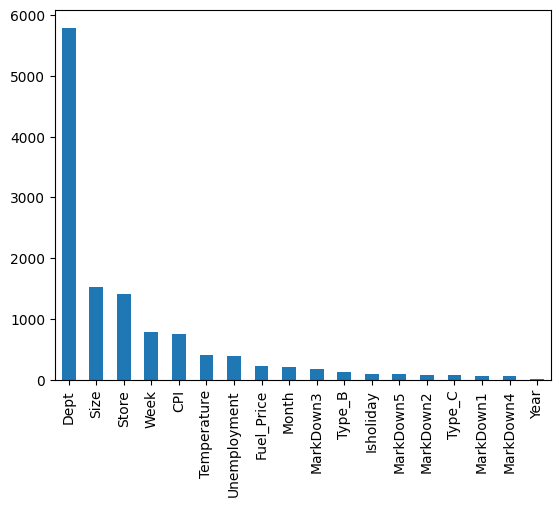

In [11]:
feat_imp = pd.Series(model.get_booster().get_score(importance_type="weight"))
feat_imp.sort_values(ascending = False).head(20).plot(kind = "bar")

In [12]:
sample = X_test.iloc[0:1]
print(sample)
print("Predicted Sales:", model.predict(sample))


     Store  Dept  Isholiday  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
100      1     1      False        49.01       3.157    6277.39   21813.16   

     MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment    Size  Year  \
100      143.1    1450.13     8483.0  219.714258         7.348  151315  2012   

     Month  Week  Type_B  Type_C  
100      1     1   False   False  
Predicted Sales: [15452.933]


In [13]:
print(X_train.columns.tolist())

['Store', 'Dept', 'Isholiday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Type_B', 'Type_C']


In [14]:
import pickle
pickle.dump(model,open("sales_model.pkl", "wb"))

In [15]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'app.py.py', 'features.csv', 'model.pkl', 'sales_model.pkl', 'stores.csv', 'train.csv', 'Walmart sales forecasting Project.ipynb', 'walmart sales model.ipynb', 'Walmart_cleaned_data.csv']


In [16]:
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Year,Month,Week
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,136727.915739,2010.968591,6.449510,25.826762
std,12.785297,30.492054,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,60980.583328,0.796876,3.243217,14.151887
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000,2010.000000,1.000000,1.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000,2010.000000,4.000000,14.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000,2011.000000,6.000000,26.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000,2012.000000,9.000000,38.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000,2012.000000,12.000000,52.000000
